# Titanic - Machine Learning from Disaster

O objetivo desta tarefa é criar um modelo que consiga prever a sobrevivencia de um passageiro ao naufrágio do titanic. Essa tarefa irá utilizar a base de dados da Kaggle e os resultados serão submetidos a plataforma afim de participar do campeonato. Para esta tarefa serão usados dois modelos:
- SVM
- XGBoost

In [54]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [55]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import src.plot_utils as pu
import src.data_utils as du
import src.model_utils as mu
from importlib import reload
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [56]:
# Importando a base de dados
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

In [57]:
train_df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [58]:
# Verificando os dados nulos
(train_df.isnull().sum() / len(train_df)) * 100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

#### Antes de fazer a correção dos dados nulos, irei verificar a distribuição original dos dados e definir três estratégias de inclusão. A inclusão dos dados faltantes será feita com base na distribuição mais parecida com os dados originais.

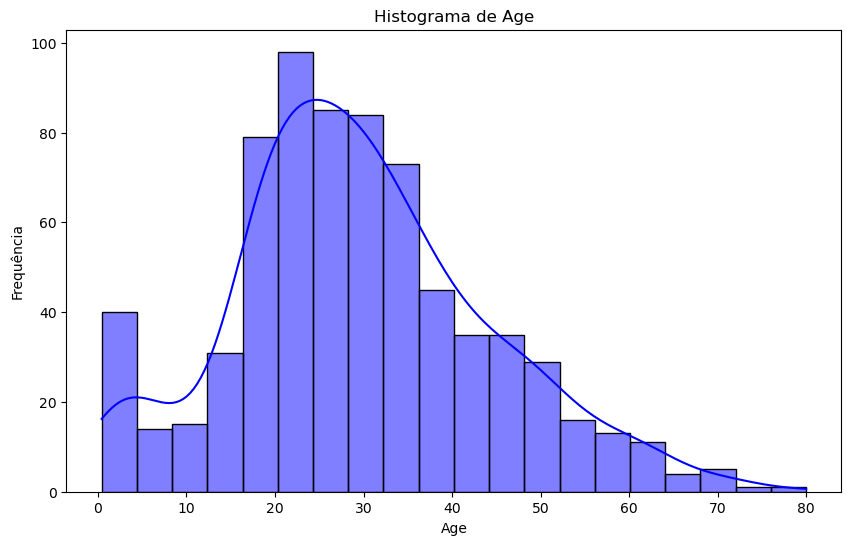

In [59]:
# Gráfico com a distribuição original dos dados, incluindo os valores nulos.
pu.plot_histograma(train_df,'Age')

In [60]:
base_original = train_df.copy()

# --- Estratégia 1: imputação pela mediana ---
base_cond_1 = du.impute_by_median(base_original, col='Age')


# --- Estratégia 2: imputação condicional utilizando o gênero ---
base_cond_2 = du.impute_by_group_median(train_df, col='Age', group_col='Sex')

# --- Estratétia 3: imputação condicional por um grupo de variáveis ---
base_cond_3 = du.impute_by_multigroup_median(train_df, col="Age", group_cols=["Sex", "Embarked"])

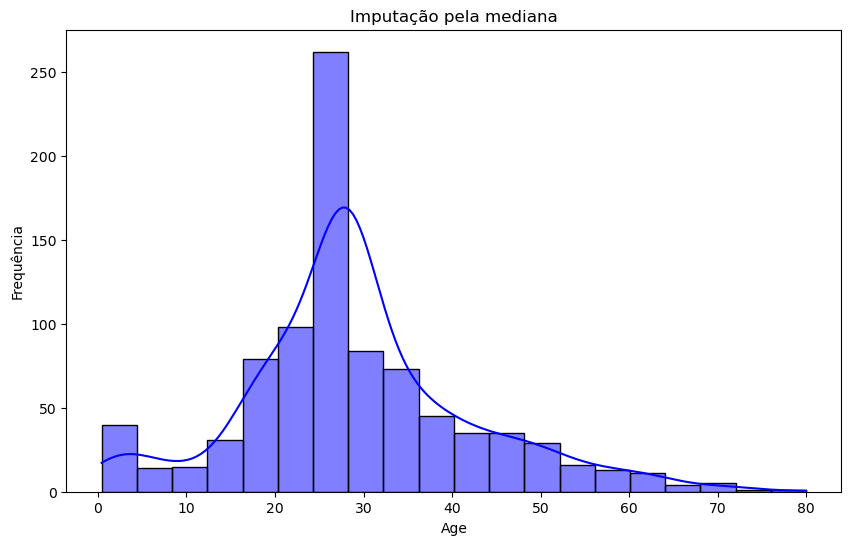

In [61]:
pu.plot_histograma(base_cond_1, 'Age', titulo='Imputação pela mediana')

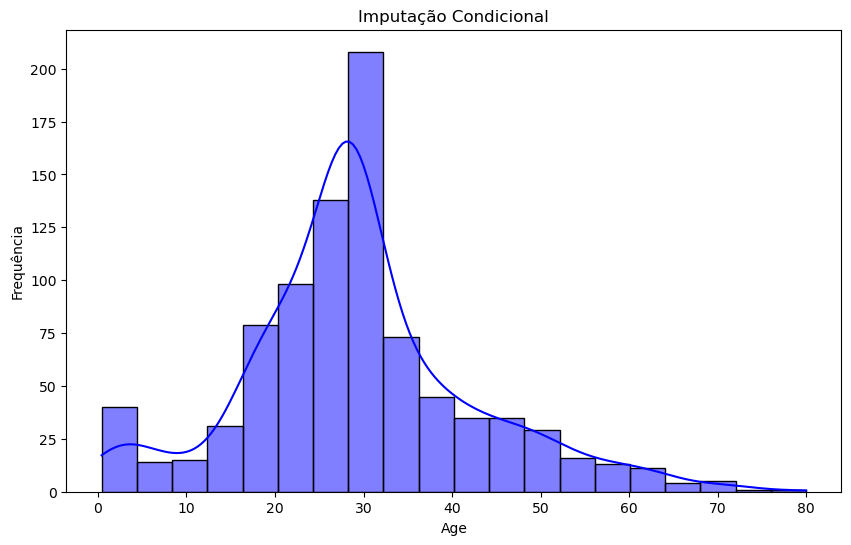

In [62]:
pu.plot_histograma(base_cond_2, 'Age', titulo='Imputação Condicional')

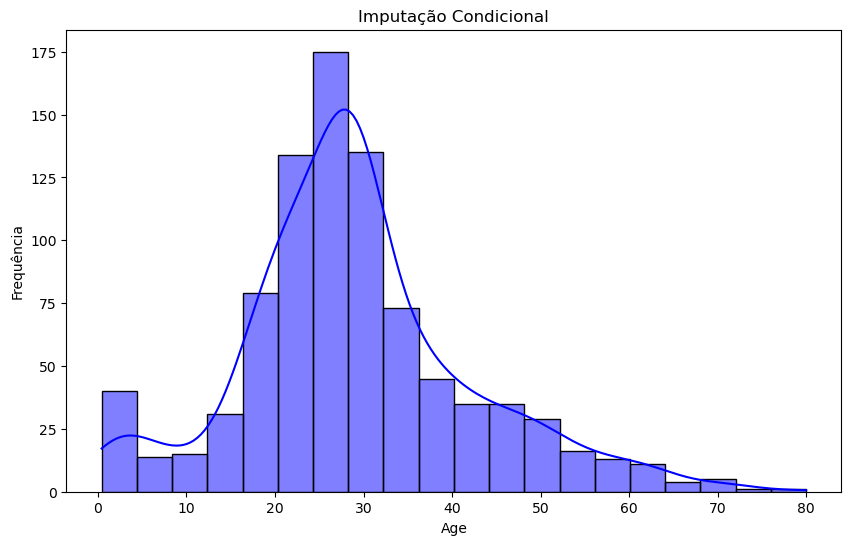

In [63]:
pu.plot_histograma(base_cond_3, 'Age', titulo='Imputação Condicional')

#### A estratégia 3 foi a que manteve a menor alteração na distribuição dos dados, portanto ela que será escolhida para a correção dos dados nulos em "Age'.

In [64]:
# fazendo o ajuste na base train e na base test
train_df = du.impute_by_multigroup_median(train_df, col="Age", group_cols=["Sex", "Embarked"])
test_df = du.impute_by_multigroup_median(test_df, col="Age", group_cols=["Sex", "Embarked"])

In [65]:
# Iniciando o pré processamento dos dados
train_df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [66]:
# Ajustando o tipo de "Age" para inteiro
train_df['Age'] = train_df['Age'].astype(int)

#### A análise univariada será feita afim de identificar possíveis outliers

In [67]:
# Verificando a presença de outiliers
train_df.describe().round(2)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,891.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.20,0.52,0.38,32.20
std,257.35,0.49,0.84,13.11,1.10,0.81,49.69
min,1.00,0.00,1.00,0.00,0.00,0.00,0.00
25%,223.50,0.00,2.00,21.00,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,35.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


In [68]:
du.comparar_media_mediana(train_df)

,média,mediana,diferença
PassengerId,446.000000,446.0000,0.000000
Survived,0.383838,0.0000,0.383838
Pclass,2.308642,3.0000,-0.691358
Age,29.198653,28.0000,1.198653
SibSp,0.523008,0.0000,0.523008
Parch,0.381594,0.0000,0.381594
Fare,32.204208,14.4542,17.750008


In [69]:
du.comparar_75_max(train_df)

,75%,max,diferença
PassengerId,668.5,891.0000,222.5000
Survived,1.0,1.0000,0.0000
Pclass,3.0,3.0000,0.0000
Age,35.0,80.0000,45.0000
SibSp,1.0,8.0000,7.0000
Parch,0.0,6.0000,6.0000
Fare,31.0,512.3292,481.3292


#### A média e a mediana estão próximas mas os 75% dos dados para o max estão bem distantes. Por isso irei gerar o boxPlot das variáveis Age e Fare para identificar possíveis erros nos dados.

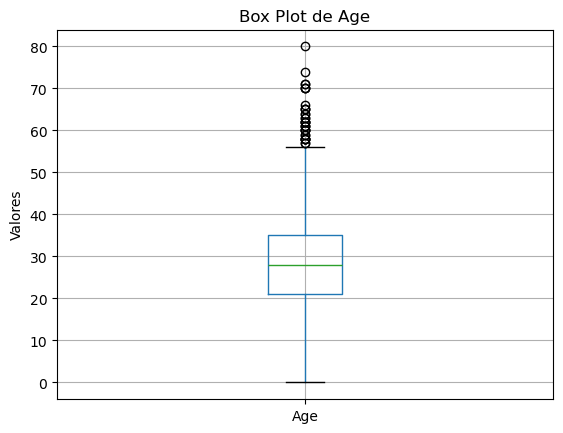

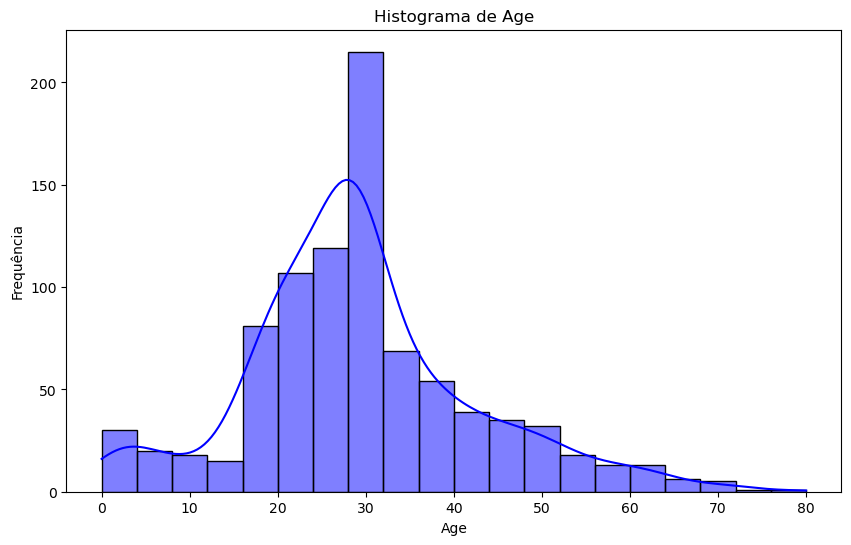

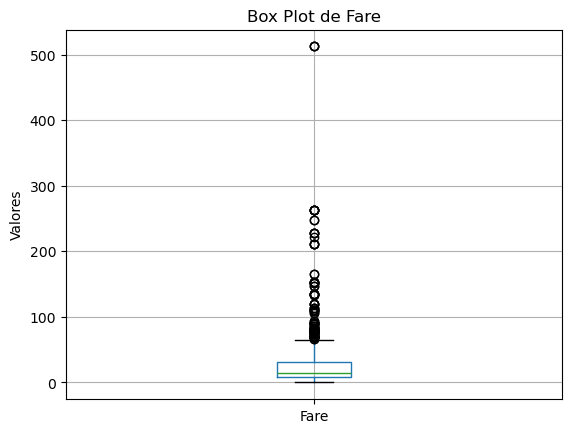

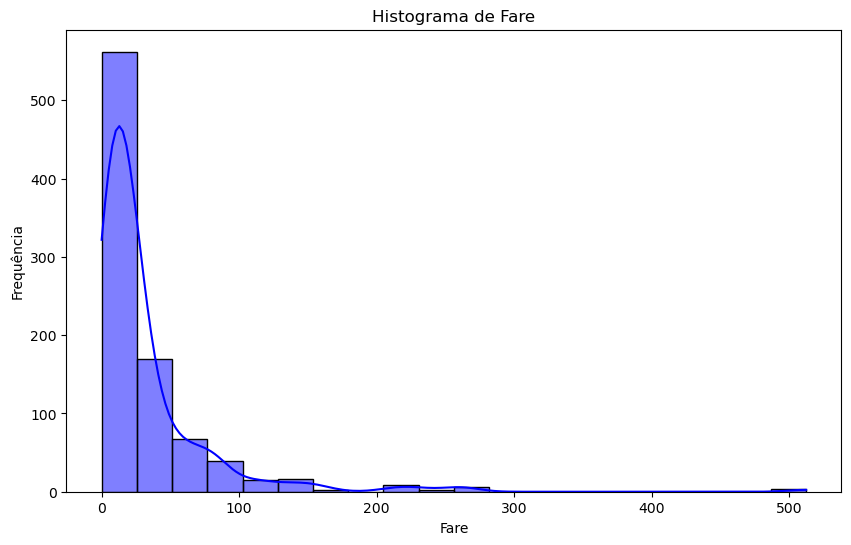

In [70]:
colunas = [
    'Age',
    'Fare'
]

for col in colunas:
    pu.plot_boxplot(train_df, col)
    pu.plot_histograma(train_df, col)

In [71]:
# Localizando outiliers
outliers = du.detectar_outliers_iqr(train_df, 'Age')
print(outliers['Age'])
print(len(outliers))   # quantidade de linhas detectadas

11     58
33     66
54     65
94     59
96     71
116    70
170    61
195    58
232    59
252    62
268    58
275    63
280    65
326    61
366    60
438    64
456    65
483    63
487    58
493    71
545    64
555    62
570    62
587    60
625    61
626    57
630    80
659    58
672    70
684    60
694    60
745    70
772    57
829    62
851    74
Name: Age, dtype: int64
35


In [72]:
# Localizando outiliers
outliers = du.detectar_outliers_iqr(train_df, 'Fare')
print(outliers['Fare'])
print(len(outliers))   # quantidade de linhas detectadas

1       71.2833
27     263.0000
31     146.5208
34      82.1708
52      76.7292
         ...   
846     69.5500
849     89.1042
856    164.8667
863     69.5500
879     83.1583
Name: Fare, Length: 116, dtype: float64
116


In [73]:
train_df.groupby("Pclass")["Fare"].describe()

,count,mean,std,min,25%,50%,75%,max
Pclass,,,,,,,,
1,216.0,84.154687,78.380373,0.0,30.92395,60.2875,93.5,512.3292
2,184.0,20.662183,13.417399,0.0,13.00000,14.2500,26.0,73.5000
3,491.0,13.675550,11.778142,0.0,7.75000,8.0500,15.5,69.5500


In [74]:
train_df.groupby("SibSp")["Fare"].describe()

,count,mean,std,min,25%,50%,75%,max
SibSp,,,,,,,,
0,608.0,25.692028,49.733052,0.0000,7.7958,9.5000,26.0000,512.3292
1,209.0,44.147370,40.380919,6.4958,16.1000,26.0000,57.0000,263.0000
2,28.0,51.753718,66.225403,7.9250,18.5625,23.7000,56.9844,262.3750
3,16.0,68.908862,96.355121,15.8500,21.0750,25.4667,27.9000,263.0000
4,18.0,31.855556,7.322546,7.9250,29.6625,31.2750,37.6125,39.6875
5,5.0,46.900000,0.000000,46.9000,46.9000,46.9000,46.9000,46.9000
8,7.0,69.550000,0.000000,69.5500,69.5500,69.5500,69.5500,69.5500


In [75]:
train_df.groupby("Parch")["Fare"].describe()

,count,mean,std,min,25%,50%,75%,max
Parch,,,,,,,,
0,678.0,25.586774,41.878786,0.0000,7.85420,10.50000,26.0000,512.3292
1,118.0,46.778180,63.709430,7.2292,17.21250,26.00000,39.6875,512.3292
2,80.0,64.337604,65.993088,7.7500,26.00000,32.88125,69.5500,263.0000
3,5.0,25.951660,7.862611,18.7500,19.25830,23.00000,34.3750,34.3750
4,4.0,84.968750,118.731099,21.0750,26.19375,27.90000,86.6750,263.0000
5,5.0,32.550000,4.101134,29.1250,31.27500,31.27500,31.3875,39.6875
6,1.0,46.900000,NaN,46.9000,46.90000,46.90000,46.9000,46.9000


#### Embora tenha detectado outiliers nos dos das variáveis 'Age' e 'Fare', após analise foi confirmado que faz sentido os valores.

#### Após essas verificações será feito o tratamento das colunas categóricas e em seguida a exclusão das colunas que não serão utilizadas no dataset.

In [76]:
# 1. Para a variável 'Sex', podemos usar Label Encoding, pois há apenas duas categorias
train_df['Sex'] = train_df['Sex'].map({'male': 0, 'female': 1})
test_df['Sex'] = test_df['Sex'].map({'male': 0, 'female': 1})

In [77]:
# 2. Para a variável 'Embarked', podemos usar One-Hot Encoding, pois há mais de duas categorias
train_df = pd.get_dummies(train_df, columns=['Embarked'], prefix='Embarked')
test_df = pd.get_dummies(test_df, columns=['Embarked'], prefix='Embarked')

In [78]:
# 3. Para a variável 'Cabin', podemos apenas criar uma nova variável indicando se a cabine é conhecida ou não
train_df['Cabin_known'] = train_df['Cabin'].notna().astype(int)
test_df['Cabin_known'] = test_df['Cabin'].notna().astype(int)

# Agora podemos descartar a coluna 'Cabin' original
train_df = train_df.drop(columns=['Cabin'])
test_df_teste = test_df.drop(columns=['Cabin'])

In [79]:
train_df = train_df.drop(columns=['Name','Ticket'])

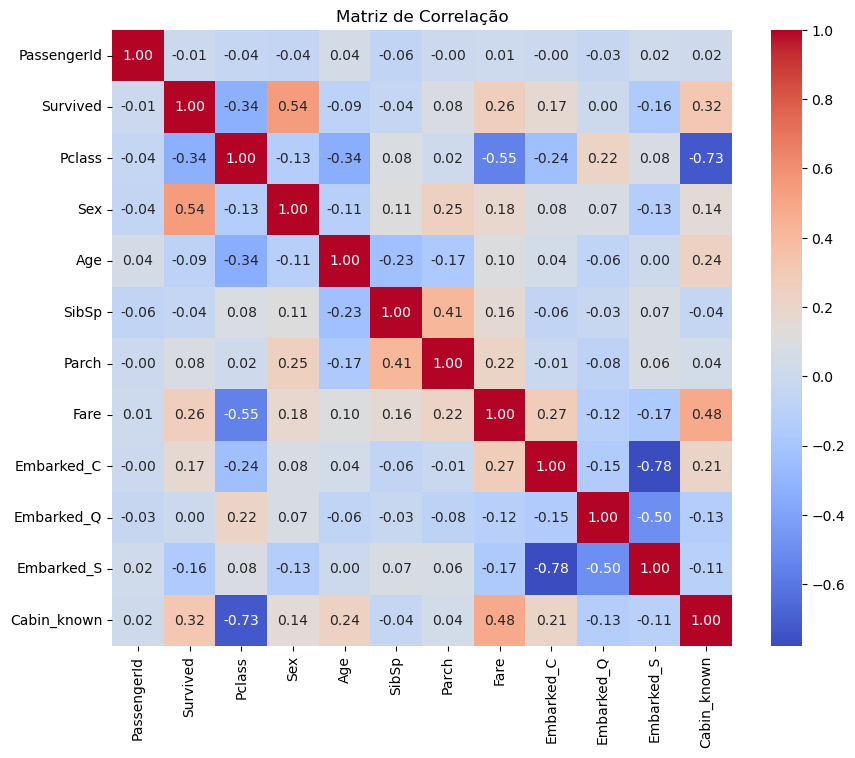

In [80]:
pu.mapa_correlacao(train_df)

In [81]:
du.correlacao_com_target(train_df, 'Survived')

,variável,correlação
0,Sex,0.543351
1,Cabin_known,0.316912
2,Fare,0.257307
3,Embarked_C,0.168240
4,Parch,0.081629
5,Embarked_Q,0.003650
6,PassengerId,-0.005007
7,SibSp,-0.035322
8,Age,-0.085409
9,Embarked_S,-0.155660


In [82]:
print(train_df['Survived'].value_counts())
print(train_df['Survived'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

Survived
0    549
1    342
Name: count, dtype: int64
Survived
0    61.62%
1    38.38%
Name: proportion, dtype: object


#### A correlação que parece estar mais forte com o target é a variavel 'Sex'. Outro ponto importante é o desbalanceamento que há nos dados de treino. Agora será feito a separação dos dados.

Dos embarked, o que tem maior correlação com o target é o s. Os outros tem uma forte correlação entre si e por isso serão removidos. O Outro problema é o Pclass que tem uma forte correlação com o cabin. Então irei fazer os seguintes testes:
1. variaveis = ['Sex', 'Fare', 'Cabin_known', 'Pclass', 'Embarked_S', 'Embarked_C']
2. variaveis = ['Sex', 'Fare', 'Cabin_known', 'Pclass', 'Embarked_S']
3. variaveis = ['Sex', 'Fare', 'Cabin_known', 'Embarked_S']

In [165]:
variaveis = ['Sex', 'Fare', 'Cabin_known', 'Pclass', 'Embarked_C']
#variaveis = ['Sex', 'Cabin_known','Fare','Pclass']

In [166]:
# Separando as variáveis dependentes (Y) e independentes (X) no conjunto de treino
X = train_df[variaveis]
Y = train_df['Survived']

X_test = test_df[variaveis]

#### Com as variáveis categóricas tratadas e a base já separada, será dado inicio a etapa de modelagem.

O primeiro modelo a ser treinado será o XGBoost, primeiro será feito o treinamento sem a utilização de hiperparâmetros. Depois será feito um novo modelo do XGBoost com os hiperparâmetros para a comparação

Depois o mesmo processo será realizado para o modelo SVM. Primeiro sem hiperparâmetros, depois com os hiperparâmetros. 

Todos os modelos usará o cross validation e a pipeline. 

In [167]:
reload(mu)

<module 'src.model_utils' from 'C:\\Users\\bruna\\OneDrive\\Documentos\\Projetos\\ebac-mod41-titanic-model-challenge\\src\\model_utils.py'>

In [168]:
# 1. Cria o pipeline sem Hiperparâmetros
pipe_boost_simple = mu.criar_pipeline_xgboost(
    n_components=None,
    random_state=42
)

In [169]:
# 2. Avalia com cross validation (só no treino)
resultado = mu.criar_cross_validation(
    pipeline=pipe_boost_simple,
    X=X,
    y=Y,
    folds=5,
    scoring='roc_auc'
)

Pontuações por fold : [0.84986825 0.86818182 0.82667112 0.86450535 0.86903337]
Média               : 0.8557
Desvio padrão       : 0.0160


In [170]:
# Gera predições cruzadas (cada amostra é predita quando estava no fold de validação)
y_pred_xg_simple = cross_val_predict(
    pipe_boost_simple,
    X,
    Y,
    cv=resultado['kfold']   # reutiliza o mesmo kfold do resultado
)

# Relatório
relatorio_xg_simple = classification_report(Y, y_pred_xg_simple)
print("Relatório de Classificação — Cross Validation:")
print(relatorio_xg_simple)

Relatório de Classificação — Cross Validation:
              precision    recall  f1-score   support

           0       0.84      0.84      0.84       549
           1       0.74      0.74      0.74       342

    accuracy                           0.80       891
   macro avg       0.79      0.79      0.79       891
weighted avg       0.80      0.80      0.80       891



In [171]:
# 1. Criar pipeline que será incluido os hiperparâmetros
pipe_boost_hiper = mu.criar_pipeline_xgboost(
    n_components=None,
    random_state=42
)

In [172]:
# 2. Grid de hiperparâmetros
# prefixo 'modelo__' indica que o parâmetro pertence ao step 'modelo' do pipeline
param_grid_xgboost = {
    'modelo__learning_rate'    : [0.01, 0.05, 0.1, 0.3],
    'modelo__max_depth'        : [3, 4, 6],
    'modelo__n_estimators'     : [50, 100, 200],
    'modelo__subsample'        : [0.5, 0.8, 1.0],
    'modelo__colsample_bytree' : [0.5, 0.8, 1.0],
}

In [173]:
# 3. StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [174]:
# 4. GridSearchCV
grid_search_xg = GridSearchCV(
    estimator=pipe_boost_hiper,
    param_grid=param_grid_xgboost,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1          # mostra progresso
)

grid_search_xg.fit(X, Y)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'modelo__colsample_bytree': [0.5, 0.8, ...], 'modelo__learning_rate': [0.01, 0.05, ...], 'modelo__max_depth': [3, 4, ...], 'modelo__n_estimators': [50, 100, ...], ...}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,with_centering,True


In [175]:
# 5. Melhores parâmetros
print("Melhores parâmetros encontrados:")
print(grid_search_xg.best_params_)
print(f"\nMelhor ROC-AUC (cv): {grid_search_xg.best_score_:.4f}")

Melhores parâmetros encontrados:
{'modelo__colsample_bytree': 1.0, 'modelo__learning_rate': 0.05, 'modelo__max_depth': 4, 'modelo__n_estimators': 200, 'modelo__subsample': 1.0}

Melhor ROC-AUC (cv): 0.8688


In [176]:
# 6. Modelo final já treinado com os melhores parâmetros
melhor_modelo_xg = grid_search_xg.best_estimator_

In [177]:
# 7. Classification report
y_pred_xg_hiper = cross_val_predict(melhor_modelo_xg, X, Y, cv=cv)
print(classification_report(Y, y_pred_xg_hiper))

              precision    recall  f1-score   support

           0       0.85      0.84      0.85       549
           1       0.75      0.76      0.75       342

    accuracy                           0.81       891
   macro avg       0.80      0.80      0.80       891
weighted avg       0.81      0.81      0.81       891



#### Terminado os treinos com o XGBoost, agora iremos partir para o SVM

In [178]:
reload(mu)

<module 'src.model_utils' from 'C:\\Users\\bruna\\OneDrive\\Documentos\\Projetos\\ebac-mod41-titanic-model-challenge\\src\\model_utils.py'>

In [179]:
# 1. Cria o pipeline sem Hiperparâmetros
pipe_svm_simple = mu.criar_pipeline_svm(
    n_components=None,
    random_state=42
)

In [180]:
# 2. Avalia com cross validation (só no treino)
resultado_svm_simple = mu.criar_cross_validation(
    pipeline=pipe_svm_simple,
    X=X,
    y=Y,
    folds=5,
    scoring='roc_auc'
)

Pontuações por fold : [0.75428195 0.74792781 0.70300802 0.7026738  0.7037628 ]
Média               : 0.7223
Desvio padrão       : 0.0236


In [181]:
# Gera predições cruzadas (cada amostra é predita quando estava no fold de validação)
y_pred_svm_simple = cross_val_predict(
    pipe_svm_simple,
    X,
    Y,
    cv=resultado_svm_simple['kfold']   # reutiliza o mesmo kfold do resultado
)

# Relatório
relatorio_svm_simple = classification_report(Y, y_pred_svm_simple)
print("Relatório de Classificação — Cross Validation:")
print(relatorio_svm_simple)

Relatório de Classificação — Cross Validation:
              precision    recall  f1-score   support

           0       0.72      0.70      0.71       549
           1       0.54      0.56      0.55       342

    accuracy                           0.65       891
   macro avg       0.63      0.63      0.63       891
weighted avg       0.65      0.65      0.65       891



In [184]:
# 1. Criar pipeline que será incluido os hiperparâmetros
pipe_svm_hiper = mu.criar_pipeline_svm(
    n_components=None,
    random_state=42,
    colunas_continuas=['Fare'],
    colunas_binarias=['Sex', 'Cabin_known','Pclass', 'Embarked_C']
)

In [185]:
X

,Sex,Fare,Cabin_known,Pclass,Embarked_C
0,0,7.2500,0,3,False
1,1,71.2833,1,1,True
2,1,7.9250,0,3,False
3,1,53.1000,1,1,False
4,0,8.0500,0,3,False
...,...,...,...,...,...
886,0,13.0000,0,2,False
887,1,30.0000,1,1,False
888,1,23.4500,0,3,False
889,0,30.0000,1,1,True


    {   # poly → gamma + degree
        'modelo__C'      : [0.01, 0.1, 1, 10, 100],
        'modelo__kernel' : ['poly'],
        'modelo__gamma'  : ['scale', 'auto', 0.001,  0.01, 0.1, 1],
        'modelo__degree' : [2, 3, 4],          # grau do polinômio
    },
    {   # kernel rbf → gamma faz diferença
        'modelo__C'      : [0.01, 0.1, 1, 10, 100],
        'modelo__kernel' : ['rbf'],
        'modelo__gamma'  : ['scale', 'auto', 0.001, 0.01, 0.1, 1],
    },

In [186]:
# 2. Grid de Hiperparâmetros
param_grid_svm = [
    {   # kernel rbf → gamma faz diferença
        'modelo__C'      : [10, 100],
        'modelo__kernel' : ['rbf'],
        'modelo__gamma'  : ['scale', 'auto', 0.001, 0.01, 0.1, 1],
    },
]
# rbf:    4 × 4 = 16 combinações
# linear: 4 × 1 =  4 combinações
# total:  20 combinações × 5 folds = 100 fits  ← mais enxuto

In [187]:
# 3. StratifiedKFold
cv_svm = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [188]:
# 4. GridSearchCV
grid_search_svm = GridSearchCV(
    estimator=pipe_svm_hiper,
    param_grid=param_grid_svm,
    cv=cv_svm,
    n_jobs=1,
    scoring='roc_auc',
    verbose=1          # mostra progresso
)

grid_search_svm.fit(X, Y)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


C:\Users\bruna\anaconda3\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
C:\Users\bruna\anaconda3\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
C:\Users\bruna\anaconda3\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
C:\Users\bruna\anaconda3\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
C:\Users\bruna\anaconda3\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1

,estimator,Pipeline(step...m_state=42))])
,param_grid,"[{'modelo__C': [10, 100], 'modelo__gamma': ['scale', 'auto', ...], 'modelo__kernel': ['rbf']}]"
,scoring,'roc_auc'
,n_jobs,1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('scaler', ...)]"


In [189]:
# 5. Melhores parâmetros
print("Melhores parâmetros encontrados:")
print(grid_search_svm.best_params_)
print(f"\nMelhor ROC-AUC (cv): {grid_search_svm.best_score_:.4f}")

Melhores parâmetros encontrados:
{'modelo__C': 10, 'modelo__gamma': 0.1, 'modelo__kernel': 'rbf'}

Melhor ROC-AUC (cv): 0.8420


In [190]:
# 6. Modelo final já treinado com os melhores parâmetros
melhor_modelo_svm = grid_search_svm.best_estimator_

In [191]:
# 7. Classification report
y_pred_svm_hiper = cross_val_predict(melhor_modelo_svm, X, Y, cv=cv_svm)
print(classification_report(Y, y_pred_svm_hiper))

C:\Users\bruna\anaconda3\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
C:\Users\bruna\anaconda3\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
C:\Users\bruna\anaconda3\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
C:\Users\bruna\anaconda3\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
C:\Users\bruna\anaconda3\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1

              precision    recall  f1-score   support

           0       0.85      0.79      0.82       549
           1       0.69      0.77      0.73       342

    accuracy                           0.78       891
   macro avg       0.77      0.78      0.77       891
weighted avg       0.79      0.78      0.78       891



Dos testes feitos com diferentes variaveis, o que retornou um melhor f1-score foi a segunda opção descrita abaixo.
1. variaveis = ['Sex', 'Fare', 'Cabin_known', 'Pclass', 'Embarked_S', 'Embarked_C']
2. variaveis = ['Sex', 'Fare', 'Cabin_known', 'Pclass', 'Embarked_S']
3. variaveis = ['Sex', 'Fare', 'Cabin_known', 'Embarked_S']

Entre os modelos de XGBoost e SVM, o melhor modelo foi o XGBoost com os hiperparametros. Então ele que será enviado para a plataforma kaggle

In [192]:
# Fazer predição no conjunto de teste do Kaggle
y_pred = melhor_modelo_xg.predict(X_test)

# Garantir que a saída seja inteira
y_pred = y_pred.astype(int)

# Montar arquivo de submissão
submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived': y_pred
})

# Salvar CSV
submission.to_csv('submission.csv', index=False)

# Visualizar resultado
print(submission.head())

   PassengerId  Survived
0          892         0
1          893         1
2          894         0
3          895         0
4          896         1
